In [6]:
# imports and parameters
import numpy as np
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import pickle
import psutil

# ---- parameters ---- #
DEM_PATH      = "sfm_2026_utm1m.tif"
CHANNEL_PATH  = "CLaSH26_channelSfM_utm.shp"
OUTPUT_PATH   = "clash_flowgraph_2026.pkl"

CELL_SIZE = 1.0 # meters (verified: -tr 1 1)
NODATA    = -9999
CHANNEL_BUF = 1.5  # meters ~ 1m ribbon on 1m  grid (stops diagonal jumps)
BURN_DROP   = 10.0 # meters below min elevation for uniform channel mask
TREE_THRESH = 50   # min nodes for a tree to be "valid" (drainage-area cutoff)

print(f"RAM: {psutil.virtual_memory().percent:.1f}%")

RAM: 9.6%


In [7]:
# stage DTM 0 -- retrieve metadata
with rasterio.open(DEM_PATH) as src:
    dem       = src.read(1).astype(np.float32)
    transform = src.transform
    crs       = src.crs
    file_nd   = src.nodata

if file_nd is not None:
    dem[dem == file_nd] = np.nan
dem[dem == NODATA] = np.nan

height, width = dem.shape
valid_mask = ~np.isnan(dem)
valid_count = int(valid_mask.sum())

print(f"Raster: {height} x {width}  ({height*width:,} cells)")
print(f"Valid : {valid_count:,} ({100*valid_count/(height*width):.1f}%)")
print(f"Elev  : {np.nanmin(dem):.1f} - {np.nanmax(dem):.1f} m")
print(f"RAM   : {psutil.virtual_memory().percent:.1f}%")

Raster: 927 x 898  (832,446 cells)
Valid : 484,284 (58.2%)
Elev  : 2380.5 - 2565.6 m
RAM   : 9.6%


In [8]:
# build the channel mask
channel = gpd.read_file(CHANNEL_PATH)

# safety: match CRS to the DEM (should already be EPSG:32613)
if channel.crs is None:
    raise ValueError("channel has no CRS")
if channel.crs.to_epsg() != crs.to_epsg():
    print(f"reprojecting channel {channel.crs.to_epsg()} to {crs.to_espg()}")
    channel = channel.to_crs(crs)
else:
    print("channel and dem crs matches")

# buffer channel line into a polygon ribbon (~3 m across)
channel_buf = channel.buffer(CHANNEL_BUF)

# rasterize ribbon onto DEM grid --> boolean channel mask
channel_mask = rasterize(
    [(geom, 1) for geom in channel_buf.geometry],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype=np.uint8,
).astype(bool)

print("rasterized buffered channel")

# only count channel cells that also have valid data
channel_mask &= valid_mask

print(f"channel cells: {channel_mask.sum():,}")
print(f"RAM: {psutil.virtual_memory().percent:.1f}%")

channel and dem crs matches
rasterized buffered channel
channel cells: 3,174
RAM: 9.6%


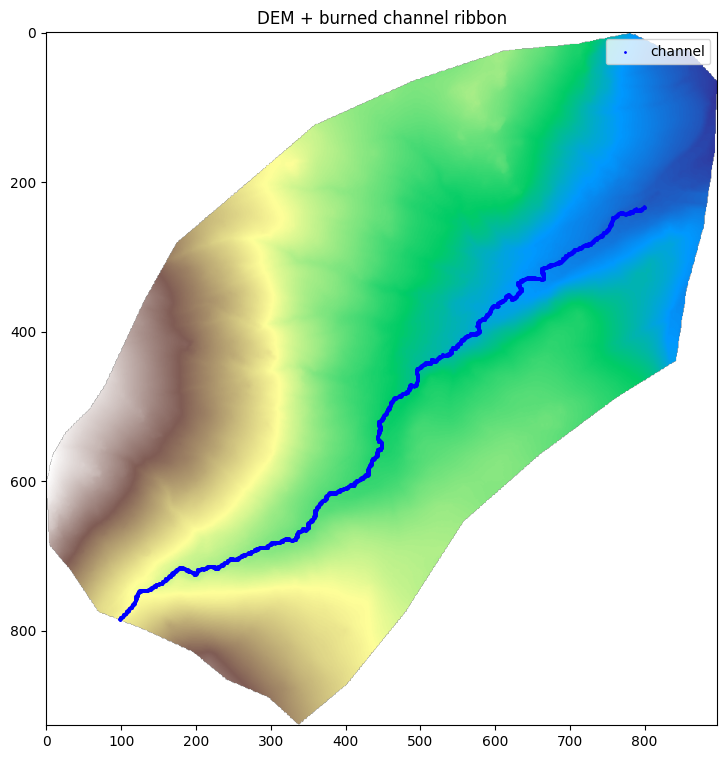

In [9]:
# quick visual: terrain + channel ribbon
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(dem, cmap='terrain')
cr, cc = np.where(channel_mask)
ax.scatter(cc, cr, s=1, c='blue', label='channel')
ax.set_title('DEM + burned channel ribbon'); ax.legend(); plt.show()

In [10]:
# burn the channel low
burn_value = float(np.nanmin(dem) - BURN_DROP)

dem_burned = dem.copy()
dem_burned[channel_mask] = burn_value

print(f"burn value: {burn_value:.1f} m  (min terrain {np.nanmin(dem):.1f} - {BURN_DROP})")
print(f"RAM: {psutil.virtual_memory().percent:.1f}%")

burn value: 2370.5 m  (min terrain 2380.5 - 10.0)
RAM: 9.7%


In [11]:
# build the flow graph
G = nx.DiGraph()
neighbors = [(-1,0),(1,0),(0,1),(0,-1),(-1,-1),(-1,1),(1,-1),(1,1)]

rows, cols = np.where(valid_mask)
valid_set = set(zip(rows.tolist(), cols.tolist())) # fast neighbor membership

channel_pit_list = []
pit_list         = []
source_list      = []

for i, (r,c) in enumerate(zip(rows, cols)):
    if i % 100000 == 0:
        print(f"  node {i:,}/{valid_count:,}  RAM {psutil.virtual_memory().percent:.1f}%")
    r = int(r); c = int(c)
    cur_id    = r * width + c
    cur_elev  = dem_burned[r,c]

    G.add_node(cur_id, dem_idx=[r,c], elev=float(cur_elev),
                is_pit=False, is_channel_pit=False, is_source=False)

    min_slope = 0.0
    max_slope = 0.0
    next_id   = cur_id
    for dr, dc in neighbors:
        nr, nc = r + dr, c + dc
        if (nr, nc) in valid_set:
            s = (dem_burned[nr, nc] - cur_elev) / (np.hypot(dr, dc) * CELL_SIZE)
            if s < min_slope:
                min_slope = s; next_id = nr * width + nc
            elif s > max_slope:
                max_slope = s

    # after calculating neighboring slopes for given node:
    if min_slope < 0:
    # if you have an outpath (steepest)
        G.add_edge(cur_id, next_id, weight=float(abs(min_slope)))
        if max_slope == 0.0:
        # if you have no inflow
            G.nodes[cur_id]["is_source"] = True
            source_list.append(cur_id)
    else:
    # if no outflow (i.e. you are a pit node)
        G.nodes[cur_id]["is_pit"] = True
        pit_list.append(cur_id)
        if channel_mask[r,c]:
        # and if you are a channel node
            G.nodes[cur_id]["is_channel_pit"] = True
            channel_pit_list.append(cur_id)

            
print(f"\n  nodes: {G.number_of_nodes():,}")
print(f"  edges: {G.number_of_edges():,}")
print(f"  channel pits: {len(channel_pit_list):,}")
print(f"  generic pits: {len(pit_list):,}")
print(f"  sources: {len(source_list):,}")
print(f"RAM: {psutil.virtual_memory().percent:.1f}%")   

  node 0/484,284  RAM 10.3%
  node 100,000/484,284  RAM 11.0%
  node 200,000/484,284  RAM 11.9%
  node 300,000/484,284  RAM 12.6%
  node 400,000/484,284  RAM 13.6%

  nodes: 484,284
  edges: 480,919
  channel pits: 3,174
  generic pits: 3,365
  sources: 298
RAM: 14.2%


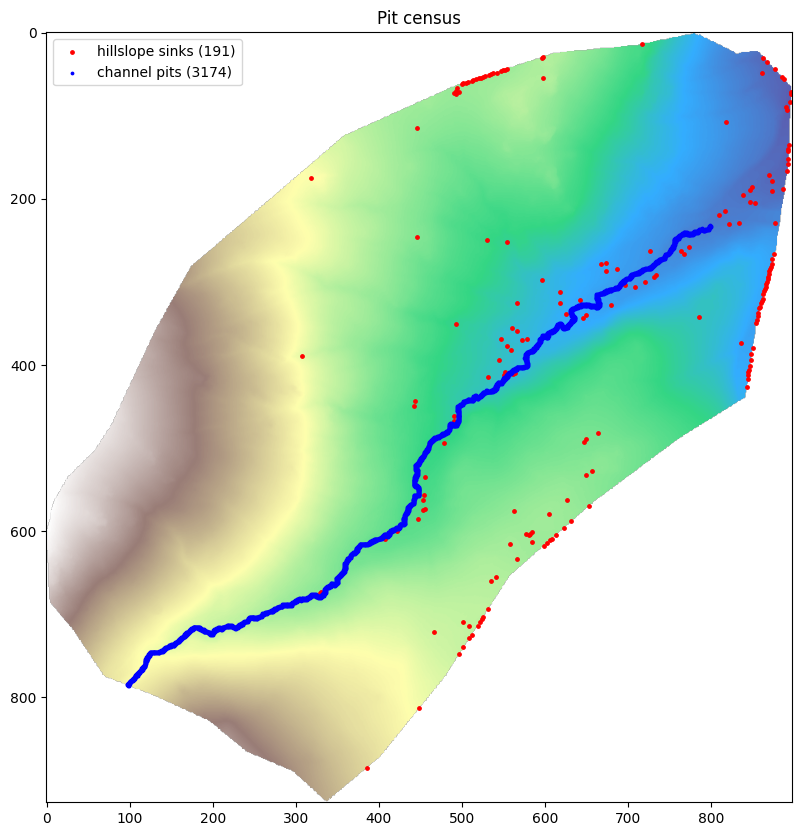

hillslope sinks (non-channel): 191 (0.039% of nodes)
channel pits: 3,174


In [12]:
# pit census -- plot channel and non- pits

channel_pit_set = set(channel_pit_list)
generic_only = [p for p in pit_list if p not in channel_pit_set]

fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(dem, cmap='terrain', alpha=0.8)

def rc(ids):
    rr = [G.nodes[n]['dem_idx'][0] for n in ids]
    cc = [G.nodes[n]['dem_idx'][1] for n in ids]
    return cc, rr

if generic_only:
    x, y = rc(generic_only);     ax.scatter(x, y, s=6, c='red',  label=f'hillslope sinks ({len(generic_only)})')
if channel_pit_list:
    x, y = rc(channel_pit_list); ax.scatter(x, y, s=3, c='blue', label=f'channel pits ({len(channel_pit_list)})')
ax.set_title('Pit census'); ax.legend(); plt.savefig('CLaSH26_sfm2026_pitcensus.png'); plt.show()

n_nodes = G.number_of_nodes()
print(f"hillslope sinks (non-channel): {len(generic_only):,} ({100*len(generic_only)/n_nodes:.3f}% of nodes)")
print(f"channel pits: {len(channel_pit_list):,}")

In [13]:
# distribution of non-channel pit distances from channel
from scipy.ndimage import distance_transform_edt

# distance (in cells = meters) from every cell to the nearest channel cell
dist_to_channel = distance_transform_edt(~channel_mask)

# distance for each non-channel pit node
sink_dists = np.array([dist_to_channel[G.nodes[p]['dem_idx'][0],
                                       G.nodes[p]['dem_idx'][1]]
                       for p in generic_only])

print(f"non-channel sinks: {len(sink_dists)}")
print(f"  min {sink_dists.min():.1f} m | median {np.median(sink_dists):.1f} m | max {sink_dists.max():.1f} m")
for D in (5, 10, 15, 20, 30, 40, 50, 60, 70):
    print(f"  within {D:>3} m of channel: {(sink_dists <= D).sum():>3}")

non-channel sinks: 191
  min 2.0 m | median 123.3 m | max 325.7 m
  within   5 m of channel:  12
  within  10 m of channel:  20
  within  15 m of channel:  33
  within  20 m of channel:  39
  within  30 m of channel:  46
  within  40 m of channel:  50
  within  50 m of channel:  54
  within  60 m of channel:  57
  within  70 m of channel:  59


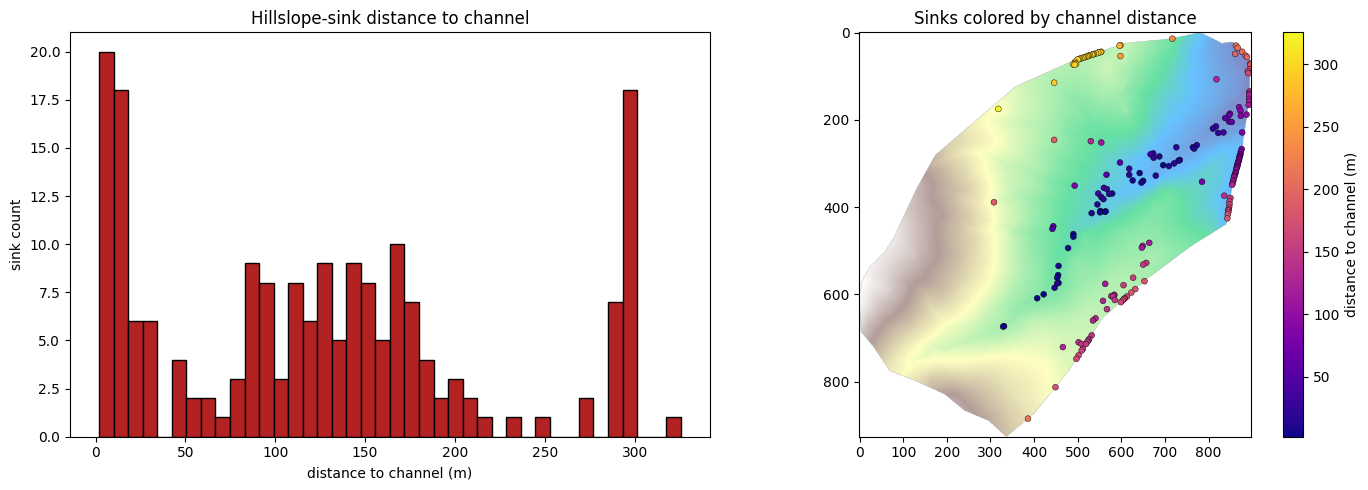

In [14]:
# plot generic-only pit node distribution

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(sink_dists, bins=40, color='firebrick', edgecolor='k')
ax[0].set_xlabel('distance to channel (m)'); ax[0].set_ylabel('sink count')
ax[0].set_title('Hillslope-sink distance to channel')

# spatial view colored by distance, to see which are the near-channel band
sr = [G.nodes[p]['dem_idx'][0] for p in generic_only]
sc = [G.nodes[p]['dem_idx'][1] for p in generic_only]
ax[1].imshow(dem, cmap='terrain', alpha=0.6)
sctr = ax[1].scatter(sc, sr, c=sink_dists, cmap='plasma', s=18, edgecolor='k', linewidth=0.3)
plt.colorbar(sctr, ax=ax[1], label='distance to channel (m)')
ax[1].set_title('Sinks colored by channel distance')
plt.tight_layout(); plt.show()

In [15]:
# --- breach near-channel hillslope sinks so their upslope flow reaches the channel ---

# D_BREACH: meters; sinks within this distance of channel get breached
# choice of D_BREACH: breach the artifacts that sever
# real flow paths to the channel
# based on histogram and spatial plot
# consistency of principle, not parameter

D_BREACH = 30.0 # 


neighbors = [(-1,0),(1,0),(0,1),(0,-1),(-1,-1),(-1,1),(1,-1),(1,1)]

# candidate sinks: non-channel pits within D_BREACH of the channel, still dead-ends
to_breach = [p for p in generic_only
             if dist_to_channel[G.nodes[p]['dem_idx'][0],
                                G.nodes[p]['dem_idx'][1]] <= D_BREACH
             and G.out_degree(p) == 0]

print(f"breaching {len(to_breach)} near-channel sinks (<= {D_BREACH:.0f} m)")

breached = 0
skipped  = 0
for pid in to_breach:
    r, c = G.nodes[pid]['dem_idx']
    cur_elev = dem_burned[r, c]
    preds = set(G.predecessors(pid))   # don't breach into an upstream cell (no 2-cycles)

    best_elev = np.inf
    best_id   = None
    best_slope = None
    for dr, dc in neighbors:
        nr, nc = r + dr, c + dc
        if (nr, nc) in valid_set:
            nid = nr * width + nc
            if nid in preds:
                continue
            ne = dem_burned[nr, nc]
            if ne < best_elev:
                best_elev = ne
                best_id   = nid
                best_slope = (ne - cur_elev) / (np.hypot(dr, dc) * CELL_SIZE)

    if best_id is None:
        skipped += 1
        continue

    # add the breach edge; weight = |slope| (may be ~0 or slightly uphill; that's ok)
    G.add_edge(pid, best_id, weight=float(abs(best_slope)))
    # this cell is no longer a pit
    G.nodes[pid]['is_pit'] = False
    breached += 1

# refresh generic pit bookkeeping
pit_list = [p for p in pit_list if G.out_degree(p) == 0]
generic_only = [p for p in pit_list if p not in set(channel_pit_list)]

print(f"  breached: {breached} | skipped (no valid neighbor): {skipped}")
print(f"  remaining non-channel sinks: {len(generic_only)}")
print(f"  edges now: {G.number_of_edges():,}")

breaching 46 near-channel sinks (<= 30 m)
  breached: 42 | skipped (no valid neighbor): 4
  remaining non-channel sinks: 149
  edges now: 480,961


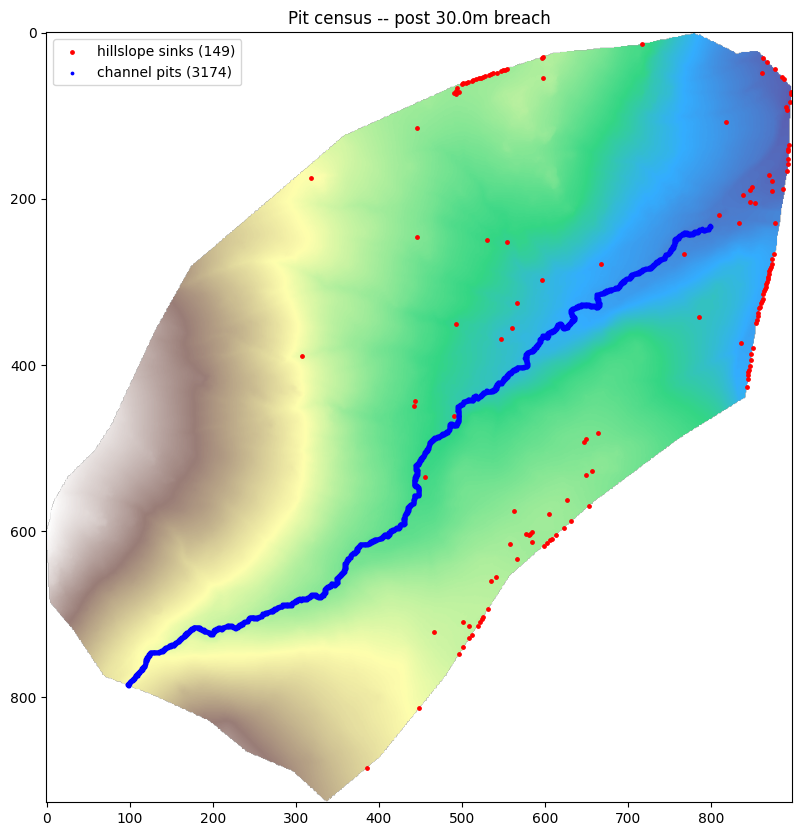

hillslope sinks (non-channel): 149 (0.031% of nodes)
channel pits: 3,174


In [16]:
# pit census pt.2 -- plot after breeching

channel_pit_set = set(channel_pit_list)
generic_only = [p for p in pit_list if p not in channel_pit_set]

fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(dem, cmap='terrain', alpha=0.8)

def rc(ids):
    rr = [G.nodes[n]['dem_idx'][0] for n in ids]
    cc = [G.nodes[n]['dem_idx'][1] for n in ids]
    return cc, rr

if generic_only:
    x, y = rc(generic_only);     ax.scatter(x, y, s=6, c='red',  label=f'hillslope sinks ({len(generic_only)})')
if channel_pit_list:
    x, y = rc(channel_pit_list); ax.scatter(x, y, s=3, c='blue', label=f'channel pits ({len(channel_pit_list)})')
ax.set_title(f'Pit census -- post {D_BREACH:.1f}m breach'); ax.legend(); plt.savefig(f'CLaSH26_sfm2026_post{int(D_BREACH)}mbreach.png'); plt.show()

n_nodes = G.number_of_nodes()
print(f"hillslope sinks (non-channel): {len(generic_only):,} ({100*len(generic_only)/n_nodes:.3f}% of nodes)")
print(f"channel pits: {len(channel_pit_list):,}")

In [17]:
# tree trace function
def trace_tree_from_pit(graph, pit_node, max_depth=200000):
    """All upstream nodes flowing into pit_node (walks predecessors)."""
    visited = set()
    to_visit = [pit_node]
    while to_visit and len(visited) < max_depth:
        cur = to_visit.pop()
        if cur in visited:
            continue
        visited.add(cur)
        to_visit.extend(graph.predecessors(cur))
    return graph.subgraph(visited).copy()

In [18]:
# trace trees
kept_trees = {}
for pid in channel_pit_list:
    tree = trace_tree_from_pit(G, pid)
    if tree.number_of_nodes() > TREE_THRESH:
        kept_trees[pid] = tree

sizes = sorted((t.number_of_nodes() for t in kept_trees.values()), reverse=True)
print(f"channel pits: {len(channel_pit_list):,}")
print(f"kept trees (> {TREE_THRESH} nodes): {len(kept_trees):,}")
if sizes:
    print(f"tree sizes: max {sizes[0]:,}, median {sizes[len(sizes)//2]:,}, min {sizes[-1]:,}")
    print(f"total nodes in kept trees: {sum(sizes):,}")
print(f"RAM: {psutil.virtual_memory().percent:.1f}%")

channel pits: 3,174
kept trees (> 50 nodes): 323
tree sizes: max 20,139, median 235, min 51
total nodes in kept trees: 255,403
RAM: 16.0%


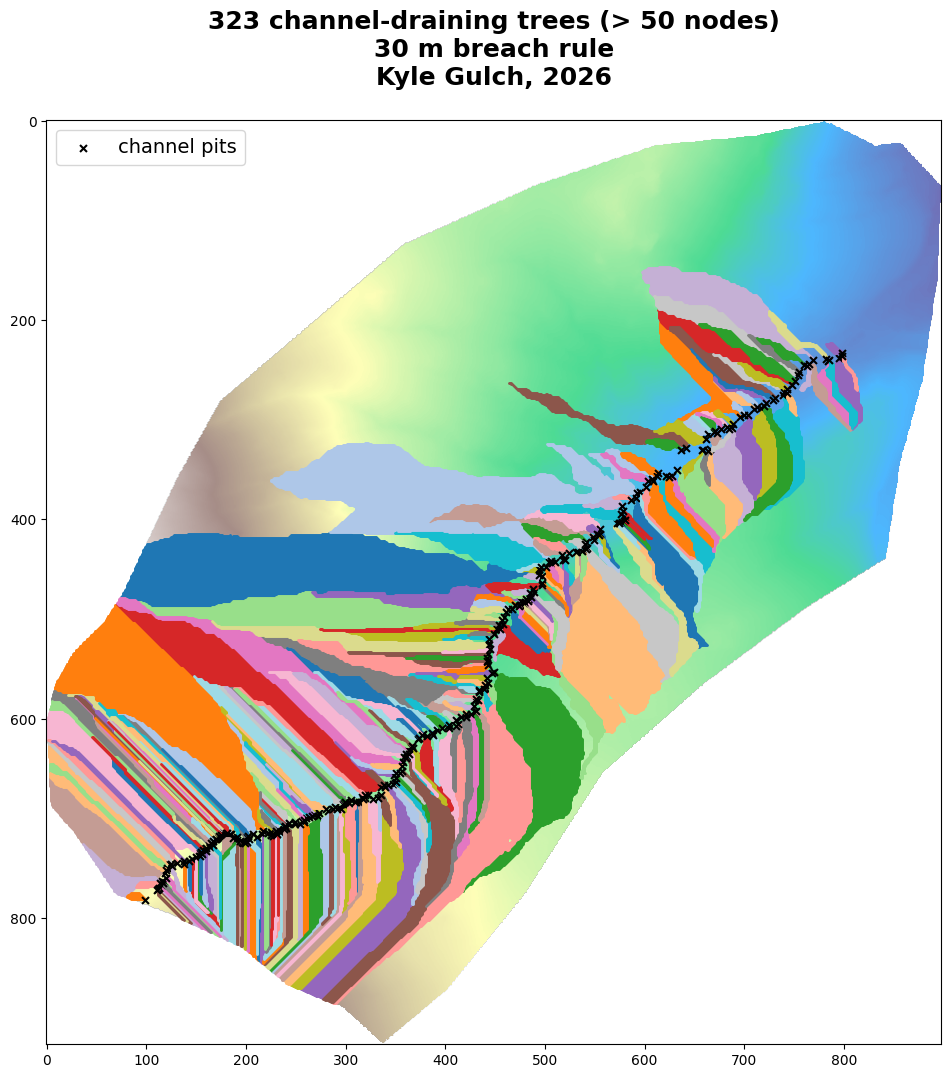

In [19]:
# draw trees on the terrain
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(dem, cmap='terrain', alpha=0.7)

cmap = plt.cm.tab20
for k, (pid, tree) in enumerate(sorted(kept_trees.items(),
                                       key=lambda kv: -kv[1].number_of_nodes())):
    rr = [G.nodes[n]['dem_idx'][0] for n in tree.nodes()]
    cc = [G.nodes[n]['dem_idx'][1] for n in tree.nodes()]
    ax.scatter(cc, rr, s=1, color=cmap(k % 20))
    pr, pc = G.nodes[pid]['dem_idx']
    ax.scatter([pc], [pr], s=25, c='black', marker='x', label=f'channel pits')

# 2. Get all legend handles and labels from the current axes
handles, labels = plt.gca().get_legend_handles_labels()



ax.set_title(f'{len(kept_trees)} channel-draining trees (> {TREE_THRESH} nodes)\n'
             f'{int(D_BREACH)} m breach rule\n'
             f'Kyle Gulch, 2026\n',fontsize=18, fontweight='bold')
# 3. Pass only the first item of each list to the legend
plt.legend([handles[0]], [labels[0]], loc='upper left',fontsize=14)
plt.savefig(f'CLaSH26_channeltrees_2026sfm_{int(D_BREACH)}mbreach.png')
plt.show()

In [21]:
# all below here pasted from Claude without verifying

In [22]:
# --- load the difference DEM and spike-filter to plausible range ---
DDEM_PATH  = "ddem_2026_2023.tif"
CLIP_ABS   = 3.0    # metres; |change| beyond this treated as blunder -> NaN

with rasterio.open(DDEM_PATH) as src:
    ddem = src.read(1).astype(np.float32)
    dd_nd = src.nodata

# nodata -> NaN
if dd_nd is not None:
    ddem[ddem == dd_nd] = np.nan

# report before clipping
finite = np.isfinite(ddem)
print(f"before clip: valid {finite.sum():,}")
print(f"  mean {np.nanmean(ddem):+.3f} m | min {np.nanmin(ddem):+.2f} | max {np.nanmax(ddem):+.2f}")

# spike filter: |change| > CLIP_ABS -> NaN (skipped downstream)
spikes = finite & (np.abs(ddem) > CLIP_ABS)
ddem[spikes] = np.nan

# report after
finite2 = np.isfinite(ddem)
print(f"after clip (|d| <= {CLIP_ABS} m): valid {finite2.sum():,} "
      f"({100*spikes.sum()/finite.sum():.2f}% removed as spikes)")
print(f"  mean {np.nanmean(ddem):+.3f} m | min {np.nanmin(ddem):+.2f} | max {np.nanmax(ddem):+.2f}")
print(f"  (sign convention: 2026-2023, + = elevation gain/deposition, - = loss/erosion)")

before clip: valid 405,796
  mean +0.886 m | min -6.39 | max +54.34
after clip (|d| <= 3.0 m): valid 361,086 (11.02% removed as spikes)
  mean +0.976 m | min -3.00 | max +3.00
  (sign convention: 2026-2023, + = elevation gain/deposition, - = loss/erosion)


In [23]:
offset = np.nanmedian(ddem)
print(f"vertical offset (median DoD over stable ground): {offset:+.3f} m")

ddem_corr = ddem - offset
print(f"after de-biasing: mean {np.nanmean(ddem_corr):+.3f} | "
      f"median {np.nanmedian(ddem_corr):+.3f} | "
      f"min {np.nanmin(ddem_corr):+.2f} | max {np.nanmax(ddem_corr):+.2f}")

vertical offset (median DoD over stable ground): +1.188 m
after de-biasing: mean -0.213 | median +0.000 | min -4.19 | max +1.81


In [24]:
# --- accumulate de-biased DoD over 2026 trees ---
tree_dod = {}   # pid -> dict of stats

for pid, tree in kept_trees.items():
    vals = []
    for n in tree.nodes():
        r, c = G.nodes[n]['dem_idx']
        v = ddem_corr[r, c]
        if np.isfinite(v):
            vals.append(v)
    n_total = tree.number_of_nodes()
    n_valid = len(vals)
    if n_valid > 0:
        vals = np.array(vals)
        tree_dod[pid] = {
            'mean':   float(vals.mean()),
            'sum':    float(vals.sum()),
            'n':      n_total,
            'n_valid': n_valid,
            'valid_frac': n_valid / n_total,
        }

print(f"trees with DoD: {len(tree_dod)} / {len(kept_trees)}")

means  = np.array([t['mean'] for t in tree_dod.values()])
fracs  = np.array([t['valid_frac'] for t in tree_dod.values()])
print(f"per-tree mean DoD: min {means.min():+.2f}, max {means.max():+.2f}, "
      f"median {np.median(means):+.2f} m")
print(f"valid fraction: min {fracs.min():.2f}, median {np.median(fracs):.2f}")
print(f"trees < 50% valid (low confidence): {(fracs < 0.5).sum()}")

trees with DoD: 319 / 323
per-tree mean DoD: min -2.25, max +1.77, median +0.48 m
valid fraction: min 0.03, median 0.97
trees < 50% valid (low confidence): 34


In [25]:
MIN_VALID_FRAC = 0.5

tree_dod = {pid: t for pid, t in tree_dod.items() if t['valid_frac'] >= MIN_VALID_FRAC}

means = np.array([t['mean'] for t in tree_dod.values()])
print(f"kept {len(tree_dod)} trees (valid_frac >= {MIN_VALID_FRAC})")
print(f"per-tree mean DoD: min {means.min():+.2f}, max {means.max():+.2f}, "
      f"median {np.median(means):+.2f} m")

kept 285 trees (valid_frac >= 0.5)
per-tree mean DoD: min -2.21, max +1.71, median +0.43 m


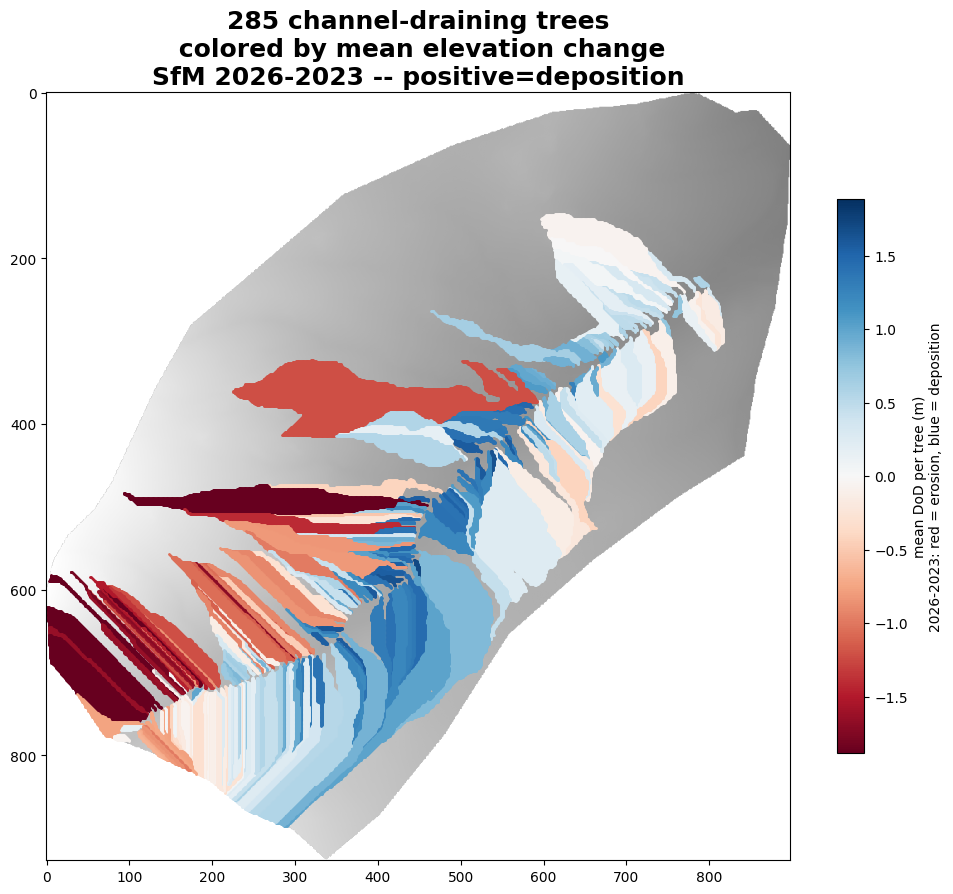

In [44]:
# --- color 2026 trees by mean de-biased DoD ---
from matplotlib.colors import TwoSlopeNorm

vmax = np.percentile(np.abs([t['mean'] for t in tree_dod.values()]), 98)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
cmap = plt.cm.RdBu   # red = negative = erosion; blue = positive = deposition

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(dem, cmap='gray', alpha=0.5)   # neutral hillshade-ish backdrop

for pid, stats in tree_dod.items():
    tree = kept_trees[pid]
    rr = [G.nodes[n]['dem_idx'][0] for n in tree.nodes()]
    cc = [G.nodes[n]['dem_idx'][1] for n in tree.nodes()]
    ax.scatter(cc, rr, s=1, color=cmap(norm(stats['mean'])))

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, shrink=0.6)
cb.set_label('mean DoD per tree (m)\n2026-2023: red = erosion, blue = deposition')

ax.set_title(f'{len(tree_dod)} channel-draining trees\n colored by mean elevation change\n'
             f'SfM 2026-2023 -- positive=deposition', fontsize=18,fontweight='bold')
#plt.savefig('CLaSH26_channelchange.png')
plt.show()

In [31]:
import geopandas as gpd

logjams = gpd.read_file("logJam_utm.shp")
if logjams.crs.to_epsg() != crs.to_epsg():
    logjams = logjams.to_crs(crs)

inv = ~transform
lj_c, lj_r = [], []
for g in logjams.geometry:
    col, row = inv * (g.x, g.y)
    lj_c.append(col); lj_r.append(row)
print(f"log jams: {len(lj_c)}")

log jams: 47


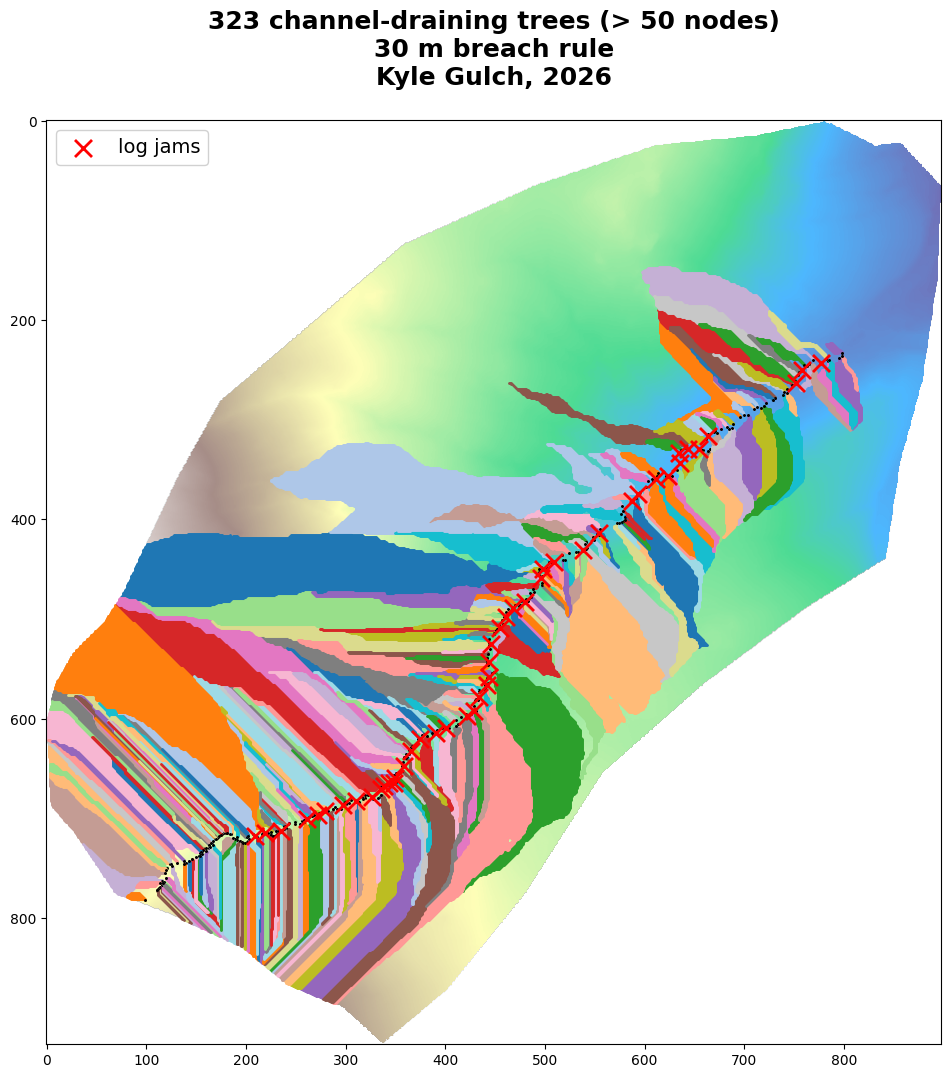

In [43]:
# draw trees on the terrain -- now with log jams
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(dem, cmap='terrain', alpha=0.7)

cmap = plt.cm.tab20
for k, (pid, tree) in enumerate(sorted(kept_trees.items(),
                                       key=lambda kv: -kv[1].number_of_nodes())):
    rr = [G.nodes[n]['dem_idx'][0] for n in tree.nodes()]
    cc = [G.nodes[n]['dem_idx'][1] for n in tree.nodes()]
    ax.scatter(cc, rr, s=1, color=cmap(k % 20))
    pr, pc = G.nodes[pid]['dem_idx']
    ax.scatter([pc], [pr], s=5, c='black', marker='.')

# 2. Get all legend handles and labels from the current axes
handles, labels = plt.gca().get_legend_handles_labels()



ax.set_title(f'{len(kept_trees)} channel-draining trees (> {TREE_THRESH} nodes)\n'
             f'{int(D_BREACH)} m breach rule\n'
             f'Kyle Gulch, 2026\n',fontsize=18, fontweight='bold')
# 3. Pass only the first item of each list to the legend
#plt.legend([handles[0]], [labels[0]], loc='upper left',fontsize=14)

ax.scatter(lj_c, lj_r, s=150, c='red', marker='x',
           linewidths=2, label='log jams', zorder=5)
ax.legend(loc='upper left', framealpha=0.9,fontsize=14)

#plt.savefig(f'CLaSH26_channeltrees_2026logjams_{int(D_BREACH)}mbreach.png')
plt.show()